In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("Compaction_notebook.ipynb")

# Geotechnical and Geoenvironmental Engineering: Soil Compaction and the Proctor Test

> **Alex Frantzis** <br> Cool Student >:3, UC Berkeley

[![License](https://img.shields.io/badge/license-CC%20BY--NC--ND%204.0-blue)](https://creativecommons.org/licenses/by-nc-nd/4.0/)
***

In this assignment, you will follow the Proctor compaction test procedure and develop code that automates the processing of laboratory data to identify the optimum moisture content and maximum dry density of a soil sample.

In [2]:
# Please run this cell, and do not modify the contents

import hashlib
def get_hash(num):
    """Helper function for assessing correctness"""
    return hashlib.md5(str(num).encode()).hexdigest()
    
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Soil Compaction
Soil compaction is the mechanical process of increasing soil density by reducing the volume of air voids within a soil mass. In geotechnical engineering, proper compaction is essential because it improves:

- Shear strength  
- Bearing capacity  
- Stiffness  
- Resistance to settlement  

Compaction is typically achieved using rollers, rammers, or vibratory equipment in the field. The effectiveness of compaction depends strongly on the **water content** of the soil.

At low water contents, soil particles experience high friction and cannot easily rearrange into a dense configuration. As water content increases, water acts as a lubricant, allowing particles to move into a more compact arrangement. Beyond a certain point, however, excess water begins to occupy space that could otherwise be filled by soil particles, reducing the achievable dry density.

This behavior leads to a characteristic peak in dry density known as the **optimum moisture content (OMC)**.

---

## The Proctor Compaction Test
The Proctor test is a laboratory procedure used to determine the relationship between **dry density** and **water content** for a given soil.

In the test:
1. Soil is mixed with a known amount of water
2. The soil is compacted into a mold using a standardized hammer
3. The bulk density and water content are measured
4. The dry density is calculated
5. The process is repeated for several water contents

The results are plotted as a **compaction curve**, with dry density on the vertical axis and water content on the horizontal axis.

The peak of this curve defines:
- **Maximum Dry Density (MDD)**
- **Optimum Water Content (OMC)**

Standardized versions of this test are defined by organizations (e.g., ASTM D698 and ASTM D1557).


## Question 1: Compaction Curve Plotting

Write a function named `fitCompactionCurve()`, that fits a polynomial curve to the **dry density versus water content** for Proctor test data.

### Input Arguments
This function has the following input arguments:

- `waterContent`, the water contents of the soil samples (in percent). This may be an array-like data type such as a list, NumPy array, or pandas Series.

- `dryDensity`, the corresponding dry densities of the soil samples (in kN/m³).

- `fitDegree`, the degree of the polynomial used to fit the compaction curve (typically 2).

### Output
- `curve`, a polynomial function fitted to the data.
---

We have provided sample code through a function called `createFigure()`, that creates a figure using the `fitCompactionCurve()` function that you create. Use it to visualize and verify your line fitting. An example curve fitted to a two degree polynomial is shown below.
<center><img src="resources/Curve_Example.png" width='650'/></center>

---
    
For testing purposes, please use np.polyfit in order to fit your polynomials. If you don't, your code may not pass the autograder. Documentation is linked below.
- np.polyfit (getting polynmial coefficients): https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html
- np.poly1d (turning coefficients into usable function): nhttps://numpy.org/doc/stable/reference/generated/numpy.poly1d.html

In [3]:
def fitCompactionCurve(waterContent, dryDensity, fitDegree):
    # Convert to NumPy arrays
    waterContent = np.array(waterContent)
    dryDensity = np.array(dryDensity)
    
    # Get polynomial coefficients using np.polyfit
    coeffs = np.polyfit(waterContent, dryDensity, fitDegree) # SOLUTION

    # Create function using np.poly1d
    curve = np.poly1d(coeffs) # SOLTION

    return curve

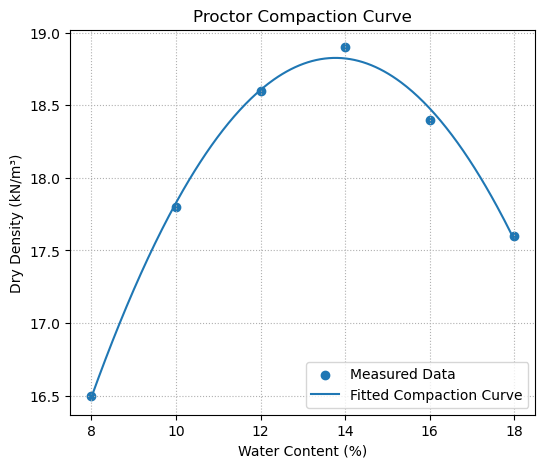

In [4]:
# Define Proctor test data
waterContent = [8, 10, 12, 14, 16, 18]          # percent
dryDensity   = [16.5, 17.8, 18.6, 18.9, 18.4, 17.6]  # kN/m^3
fitDegree = 2 # Degree of polynomial to be fitted.

def createFigure(waterContent, dryDensity, fitDegree):

    # Get the fitted curve using fitCompactionCurve
    poly_fn = fitCompactionCurve(waterContent, dryDensity, fitDegree)
    
    # Plot
    w_smooth = np.linspace(min(waterContent), max(waterContent), 300)
    gamma_smooth = poly_fn(w_smooth)
    
    fig_1 = plt.figure(figsize=(6, 5))

    plt.scatter(waterContent, dryDensity, label="Measured Data")
    plt.plot(w_smooth, gamma_smooth, label="Fitted Compaction Curve")

    plt.xlabel("Water Content (%)")  
    plt.ylabel("Dry Density (kN/m³)") 
    plt.title("Proctor Compaction Curve") 
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.8)

    return fig_1


fig = createFigure(waterContent, dryDensity, fitDegree)


In [5]:
# TEST YOUR FUNCTION HERE
waterContent = [8, 10, 12, 14, 16, 18]          # percent
dryDensity   = [16.5, 17.8, 18.6, 18.9, 18.4, 17.6]  # kN/m^3
fitDegree = 2

q1 = fitCompactionCurve(waterContent, dryDensity, fitDegree) # SOLUTION
testWaterContent = 13

# print result
print(f'polynomial fit approximates dry density at water content of {testWaterContent} to be {q1(testWaterContent)} kN/m^3')

polynomial fit approximates dry density at water content of 13 to be 18.784374999999955 kN/m^3


In [6]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to test your function!
""" # END TEST CONFIG

# Check students tested the function (type is not ellipsis)
assert get_hash(type(q1)) != '14e736438b115821cbb9b7ac0ba79034'

In [7]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Your curve is well off the given solution
success_message: Curve is close to given solution :D
""" # END TEST CONFIG

# Define Proctor test data
waterContent = [8, 10, 12, 14, 16, 18]          # percent
dryDensity   = [16.5, 17.8, 18.6, 18.9, 18.4, 17.6]  # kN/m^3
fitDegree = 2

poly_fn = fitCompactionCurve(waterContent, dryDensity, fitDegree)
assert get_hash(np.round(poly_fn(9), 1)) == '1b7f864ac7a422c1a24c720d543e7e0f'
assert get_hash(np.round(poly_fn(10), 1)) == '1383c2b19889c144c1c67203d8f7d201'
assert get_hash(np.round(poly_fn(11), 1)) == '2915286d7ad2c7a98aa7d4bb99a6af5c'
assert get_hash(np.round(poly_fn(12), 1)) == 'f956db20c1a24280c453c61bbb1ec9f6'
assert get_hash(np.round(poly_fn(13.4), 1)) == '4652e04e446dd7e02c704d4189292a1c'
assert get_hash(np.round(poly_fn(17), 1)) == 'd2de50745be374846c0b044a1d67d7a1'

## Degree of Saturation Lines

Degree of saturation lines show the relationship between **dry density** and **water content** at fixed saturation levels. The degree of saturation is the ratio of water volume to void volume:

$$
S = \frac{V_w}{V_v}
$$

where:
- $V_w$ is the volume of water  
- $V_v$ is the volume of voids  

The dry density corresponding to a given degree of saturation is:

$$
\gamma_d = \frac{G_s \, \gamma_w}{1 + \frac{w \, G_s}{S}}
$$

where:
- $\gamma_d$ is dry density  
- $G_s$ is the specific gravity of solids  
- $\gamma_w$ is the unit weight of water  
- $w$ is water content (decimal)  
- $S$ is degree of saturation (decimal)  

The **100% saturation line** ($S = 1.0$) is called the **Zero Air Voids (ZAV) line** and represents the maximum theoretical dry density. Real compaction data should always lie below this line.  

### Engineering Significance

Plotting saturation lines alongside the compaction curve helps engineers:

- Verify the physical realism of laboratory data  
- Understand why dry density decreases at high water contents  
- Visualize the role of air voids during compaction  
- Identify unrealistic or erroneous test results  

In practice, most compacted soils at optimum water content have degrees of saturation between **80% and 95%**.


## Question 2: Degree of Saturation Lines

Write a function named `getSaturationDensity()`, that calculates the theoretical dry density corresponding to different degrees of saturation and water content. Use the formula derived above.

### Input Arguments
This function has the following input arguments:

- `waterContent`, the water contents of the soil samples (in percent). This may be an array-like data type such as a list, NumPy array, or pandas Series.

- `specificGravity`, the specific gravity of the solids in the soil. 

- `saturation`, the saturation of the soil.

### Output
- `dryDensity`, the theoretical dry density of the sample using the equation given above.

In [8]:
def getSaturationDensity(waterContent, specificGravity, saturation, gamma_w = 9.81):
    # Convert waterContent to np.array
    waterContent = np.array(waterContent)
    
    # Convert percentage to decimal
    waterContent = waterContent / 100 # SOLUTION

    dryDensity = specificGravity *  gamma_w/ (1 + waterContent * specificGravity/saturation) # SOLUTION
    return dryDensity

## Relative Compaction (R) and Relative Density (Dᵣ)

Two commonly used measures of soil compactness in geotechnical engineering are **relative compaction (R)** and **relative density (Dᵣ)**. Although both describe how dense a soil is, they are used for **different soil types** and applications.

---

### Relative Compaction (R)

**Relative compaction** is primarily used for **cohesive and mixed soils** in earthwork construction. It compares the dry unit weight achieved in the field to the maximum dry unit weight obtained from a laboratory Proctor test.

$$
R = \frac{\gamma_{d,\text{field}}}{\gamma_{d,\text{max}}}
$$

where:
- $\gamma_{d,\text{field}}$ is the in-place (field) dry unit weight  
- $\gamma_{d,\text{max}}$ is the maximum dry unit weight from the Proctor test  

Relative compaction is usually expressed as a percentage:

$$
R(\%) = \frac{\gamma_{d,\text{field}}}{\gamma_{d,\text{max}}} \times 100
$$

Typical specifications require relative compaction values between **90% and 95%**.

---

### Relative Density (Dᵣ)

**Relative density** is used for **coarse-grained soils** such as sands and gravels. It compares the current void ratio of a soil to its loosest and densest possible states.

$$
D_r = \frac{e_{\text{max}} - e}{e_{\text{max}} - e_{\text{min}}}
$$

where:
- $e$ is the current void ratio  
- $e_{\text{max}}$ is the void ratio in the loosest state  
- $e_{\text{min}}$ is the void ratio in the densest state  

Relative density is also expressed as a percentage:

$$
D_r(\%) = \frac{e_{\text{max}} - e}{e_{\text{max}} - e_{\text{min}}} \times 100
$$

---

### Key Differences and Engineering Use

- **Relative compaction (R)** is based on **dry unit weight** and Proctor test results  
- **Relative density (Dᵣ)** is based on **void ratio** and applies to granular soils  
- $R$ is commonly specified in construction contracts  
- $Dᵣ$ is commonly used in analysis of sand behavior, settlement, and liquefaction  

While both quantities describe soil compactness, they are **not interchangeable** and must be applied to the appropriate soil type.


## Field Compaction Evaluation Using Proctor Test Data

In this section, you will use the functions you have developed to visualize compaction behavior and evaluate the quality of **in situ soil compaction**.

Suppose you are on a construction site and are tasked with verifying that the soil has been compacted to meet the following specifications:

- **Relative compaction requirement:** 95%  
- **Moisture content requirement:** within ±2% of the optimum water content  

Your task is to evaluate each in situ soil sample and determine whether it satisfies the project specifications. Use the Proctor test data, the fitted compaction curve, and the provided graphing tools to support your analysis.

---

### Given Proctor Test Data

The following laboratory Proctor test data were obtained for the soil:

```python
waterContent = [12.7, 14.4, 16.0, 16.7, 18.2]      # percent
dryDensity   = [15.63, 17.72, 17.46, 17.15, 16.30] # kN/m^3## Evaluation Task
```
---
### Given In Situ Soil Data

Field measurements of moisture content and dry density are as follows:

```python
inSituWaterContent = [13.0, 14.75, 15.0, 16.0, 17.0]   # percent
inSituDryDensity   = [17.4, 17.3, 17.5, 17.0, 18.2]    # kN/m^3
```
The specific gravity of the soil solids is given as:
```python
G_s = 2.67
```
---
### Answer Format

Provide your final answer in the designated answer cell as an array of the form:

```python
q3 = ['X', 'X', 'X', 'X', 'X']
```
called `q3` where each 'X' corresponds to the classification of a single in situ soil sample.

Each soil location should be classified according to the following criteria:

- **'A'** — The soil sample meets all specifications  
- **'B'** — The moisture content is outside the allowable range  
- **'C'** — The data appears unreasonable and should be retested (saturation line check) 
- **'D'** — The soil does not meet the required relative compaction  

If a soil sample exhibits multiple issues, **any applicable classification will be accepted as correct**. You may modify or extend the provided plotting code to aid your decision-making process.



In [50]:
# Answer goes here
q3 = ['B', 'A', 'A', 'D', 'C'] # SOLUTION

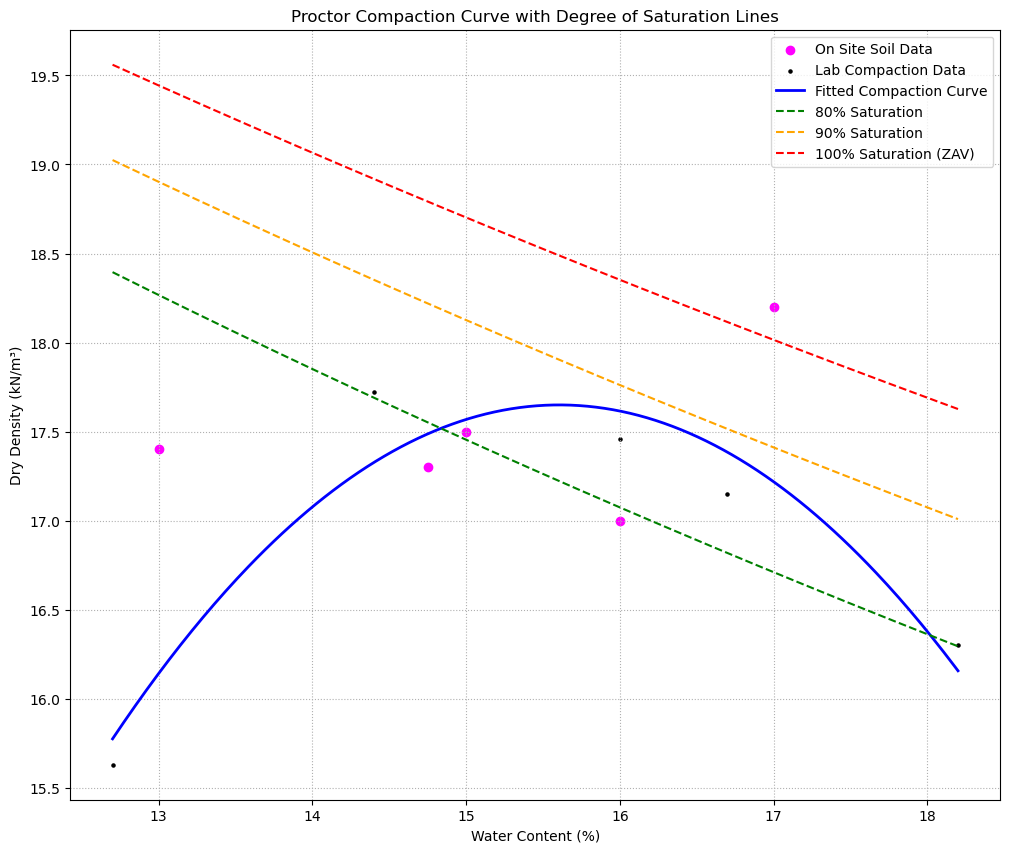

In [52]:
# PLOTTING HELPER CODE

# Define Proctor test data
waterContent = [12.7, 14.4, 16, 16.7, 18.2]          # percent
dryDensity   = [15.63, 17.72, 17.46, 17.15, 16.3]  # kN/m^3
fitDegree = 2 # Degree of polynomial to be fitted

# Define in situ soil data
inSituWaterContent = [13, 14.75, 15, 16, 17]          # percent
inSituDryDensity   = [17.4, 17.3, 17.5, 17, 18.2]  # kN/m^3

# Define specific gravity and saturation data for saturation lines.
Gs = 2.67          # specific gravity of solids
S_values = [0.8, 0.9, 1.0] # Saturation curve values.

def createFigure(waterContent, dryDensity, fitDegree, inSituWaterContent, inSituDryDensity):

    # Convert to NumPy arrays
    waterContent = np.array(waterContent)
    dryDensity = np.array(dryDensity)
    inSituWaterContent = np.array(inSituWaterContent)
    inSituDryDensity = np.array(inSituDryDensity)

    # Get the fitted curve using fitCompactionCurve
    poly_fn = fitCompactionCurve(waterContent, dryDensity, fitDegree)
    
    # Smooth range for plotting
    w_smooth = np.linspace(min(waterContent), max(waterContent), 300)
    gamma_smooth = poly_fn(w_smooth)

    # Degree of Saturation Lines
    saturation_curves = {}

    for saturation in S_values:
        gamma_d = getSaturationDensity(w_smooth, Gs, saturation)
        saturation_curves[saturation] = gamma_d

    
    # Plot
    fig_1 = plt.figure(figsize=(12, 10))

    plt.scatter(
        inSituWaterContent, inSituDryDensity,
        color="magenta", label="On Site Soil Data"
    )

    
    plt.scatter(
        waterContent, dryDensity,
        color="black", label="Lab Compaction Data", s = 5
    )

    plt.plot(
        w_smooth, gamma_smooth,
        color="blue", linewidth=2,
        label="Fitted Compaction Curve"
    )

    plt.plot(
        w_smooth, saturation_curves[0.8],
        linestyle="--", color="green",
        label="80% Saturation"
    )

    plt.plot(
        w_smooth, saturation_curves[0.9],
        linestyle="--", color="orange",
        label="90% Saturation"
    )

    plt.plot(
        w_smooth, saturation_curves[1.0],
        linestyle="--", color="red",
        label="100% Saturation (ZAV)"
    )

    plt.xlabel("Water Content (%)")
    plt.ylabel("Dry Density (kN/m³)")
    plt.title("Proctor Compaction Curve with Degree of Saturation Lines")
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.8)

    return fig_1


fig = createFigure(waterContent, dryDensity, fitDegree, inSituWaterContent, inSituDryDensity)
